# Análise Exploratória de Dados (EDA) - Predição de Atrasos Olist
**Instituição:** Instituto Federal do Amazonas (IFAM)  
**Autor:** Christian  

Este notebook tem como objetivo compreender o comportamento dos dados de logística do Olist antes da modelagem preditiva. Vamos analisar o desbalanceamento das classes, o impacto geográfico e o comportamento das categorias de produtos em relação aos atrasos nas entregas.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas para os gráficos do relatório
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

In [16]:
# Carregando as bases necessárias para a exploração
orders = pd.read_csv('datasets/olist_orders_dataset.csv')
items = pd.read_csv('datasets/olist_order_items_dataset.csv')
products = pd.read_csv('datasets/olist_products_dataset.csv')
customers = pd.read_csv('datasets/olist_customers_dataset.csv')

# Filtrando apenas pedidos entregues
orders = orders[orders['order_status'] == 'delivered'].copy()

# Tratamento de datas
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Criando a nossa variável alvo (Target)
orders['atrasou'] = (orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']).astype(int)

# Unificando dados de produtos e clientes para a análise gráfica
items_prod = items.merge(products, on='product_id', how='left')
orders_completo = orders.merge(items_prod, on='order_id', how='left').merge(customers, on='customer_id', how='left')

## 1. O Grande Desafio: Desbalanceamento de Classes
Antes de treinar qualquer modelo, precisamos entender a proporção da nossa variável alvo (`atrasou`). Modelos de Machine Learning tendem a ignorar a classe minoritária se não tratarmos esse desequilíbrio previamente.

/tmp/ipykernel_241350/3493673271.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Prazo (0)', 'Atrasou (1)'])


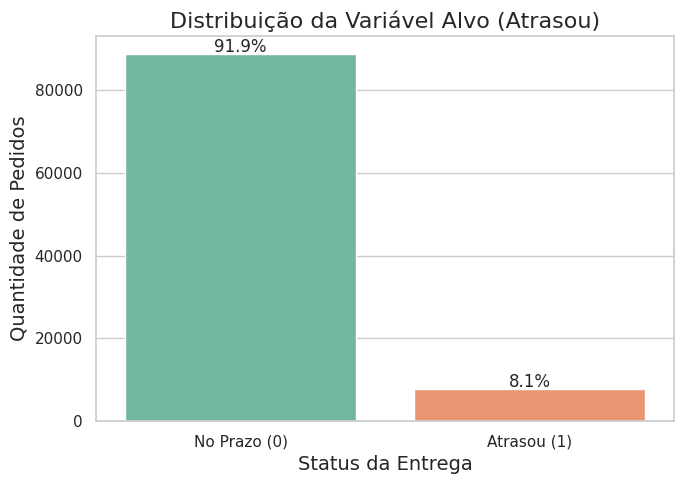

In [17]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='atrasou', data=orders, hue='atrasou', palette='Set2', legend=False)
ax.set_xticklabels(['No Prazo (0)', 'Atrasou (1)'])
plt.title('Distribuição da Variável Alvo (Atrasou)')
plt.xlabel('Status da Entrega')
plt.ylabel('Quantidade de Pedidos')

# Adicionando porcentagens no topo das barras
total = len(orders)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 500), ha='center', va='baseline')

plt.tight_layout()
plt.show()

## 2. Acomodação do Erro: Dias Estimados de Logística
Vamos analisar a distribuição dos dias estimados que a plataforma passa para o cliente (`dias_estimados_logistica`) e entender se prazos muito curtos geram mais atrasos.

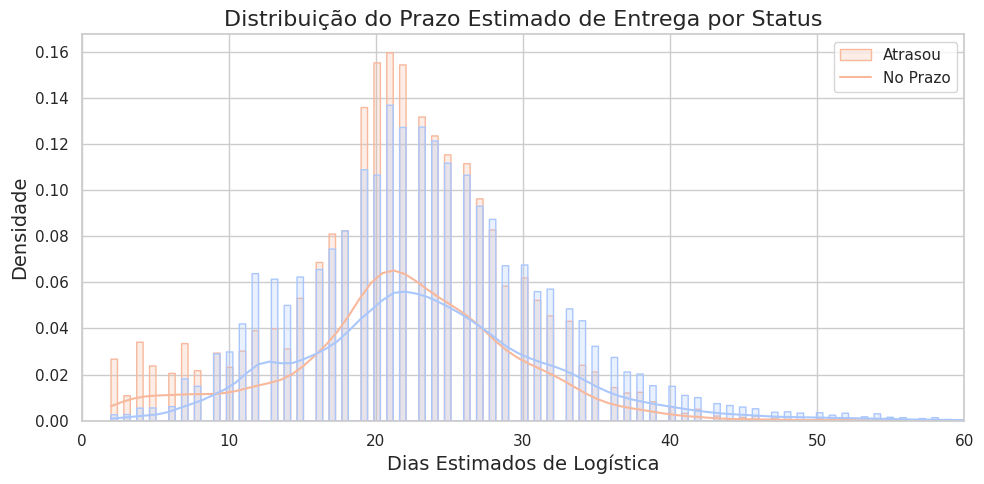

In [18]:
orders['dias_estimados_logistica'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days

plt.figure(figsize=(10, 5))
sns.histplot(data=orders, x='dias_estimados_logistica', hue='atrasou', kde=True, element='step', palette='coolwarm', stat='density', common_norm=False)
plt.title('Distribuição do Prazo Estimado de Entrega por Status')
plt.xlabel('Dias Estimados de Logística')
plt.ylabel('Densidade')
plt.xlim(0, 60)
plt.legend(['Atrasou', 'No Prazo'])
plt.tight_layout()
plt.show()

## 3. Impacto Geográfico: Onde estão os maiores gargalos?
O frete e a distância influenciam o atraso? Vamos avaliar quais estados de destino (`customer_state`) sofrem mais com a espera logística.

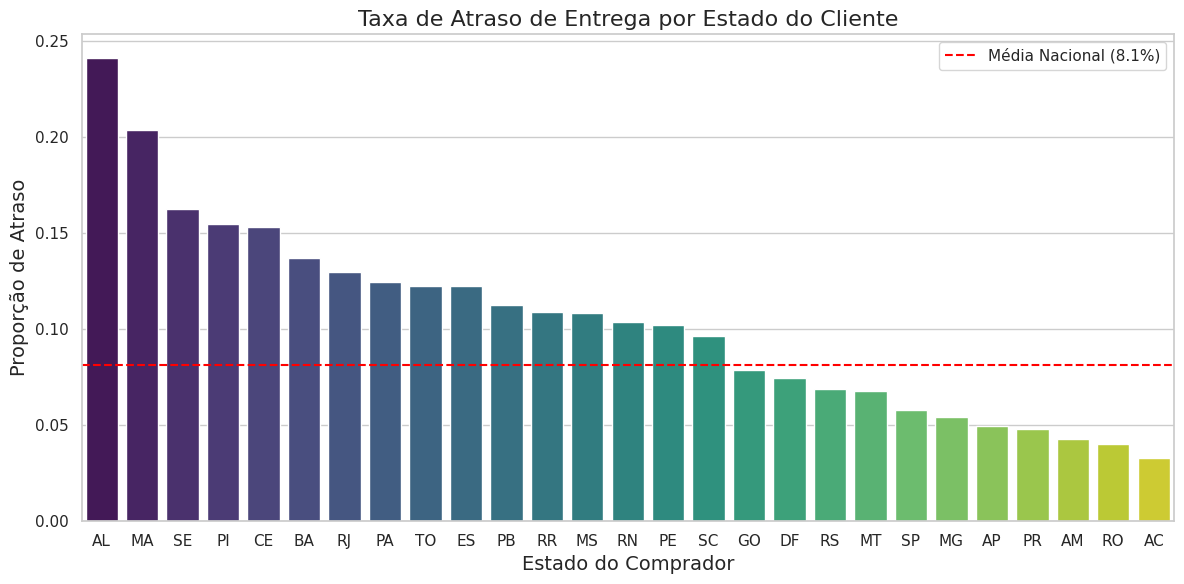

In [19]:
# Calculando a taxa de atraso média por estado do cliente
estado_atraso = orders_completo.groupby('customer_state')['atrasou'].mean().reset_index().sort_values(by='atrasou', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='customer_state', y='atrasou', data=estado_atraso, hue='customer_state', palette='viridis', legend=False)
plt.axhline(orders['atrasou'].mean(), color='red', linestyle='--', label=f'Média Nacional ({orders["atrasou"].mean()*100:.1f}%)')
plt.title('Taxa de Atraso de Entrega por Estado do Cliente')
plt.xlabel('Estado do Comprador')
plt.ylabel('Proporção de Atraso')
plt.legend()
plt.tight_layout()
plt.show()

## 4. O Efeito do Produto na Logística
Mapear a taxa de atraso por categoria revela se o problema está associado ao tipo de produto comprado. Categorias volumosas ou pesadas (Móveis, Eletrodomésticos) tendem a apresentar maior complexidade de transporte.

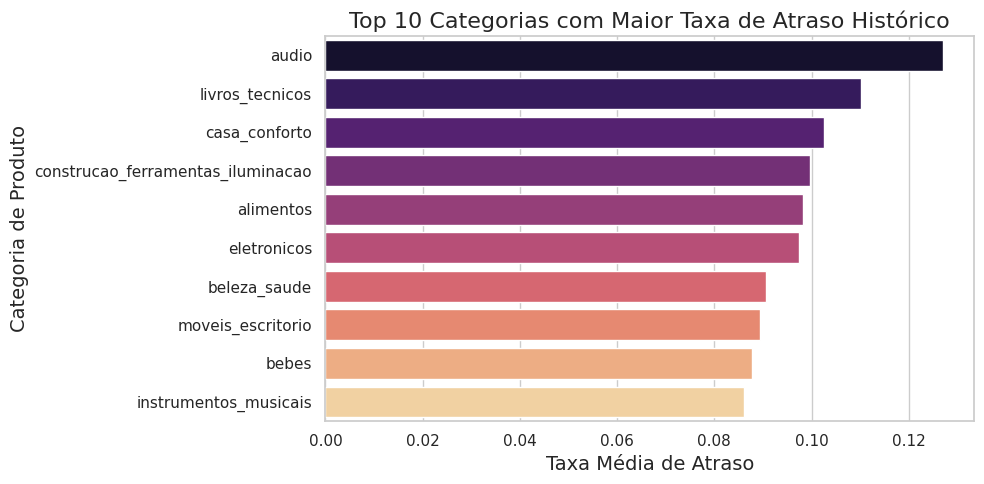

In [20]:
# Filtrando categorias com amostragem relevante (ex: mais de 200 pedidos)
categoria_counts = orders_completo['product_category_name'].value_counts()
categorias_relevantes = categoria_counts[categoria_counts > 200].index

categoria_atraso = orders_completo[orders_completo['product_category_name'].isin(categorias_relevantes)]
categoria_atraso = categoria_atraso.groupby('product_category_name')['atrasou'].mean().reset_index()
categoria_atraso = categoria_atraso.sort_values(by='atrasou', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='atrasou', y='product_category_name', data=categoria_atraso, hue='product_category_name', palette='magma', legend=False)
plt.title('Top 10 Categorias com Maior Taxa de Atraso Histórico')
plt.xlabel('Taxa Média de Atraso')
plt.ylabel('Categoria de Produto')
plt.tight_layout()
plt.show()

## Conclusões Extraídas da EDA para a Banca do IFAM

1. **Desbalanceamento Crítico:** Cerca de 8% a 9% da base histórica representa atrasos. Isso justifica cientificamente o uso do `RandomUnderSampler` no pipeline definitivo para balancear o aprendizado.
2. **Assimetria Geográfica Clara:** Estados da região Norte e Nordeste (como AL, MA, AM) exibem taxas de atraso que dobram a média nacional, validando a criação da feature de engenharia `fluxo_logistico` que combina Origem e Destino.
3. **Padrão de Produto:** Há discrepâncias entre os tipos de mercadoria. A transformação por Target Encoding (`taxa_atraso_categoria`) condensa essa variação sem sobrecarregar a dimensionalidade do modelo.